In [8]:
import torch
import torchcodec
from datasets import load_dataset

ds = load_dataset("rodriler/isolated-guitar-chords")

## Functions for feature extraction

(Add to their own pre-processing package later)

In [4]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def extract_chroma_cqt(source):
    if isinstance(source, str):
        # File path
        waveform, sr = librosa.load(source, sr=22050)
    else:
        audio = source["audio"].get_all_samples()
        waveform = audio.data.cpu().numpy()
        if waveform.ndim == 2:
            waveform = waveform.mean(axis=0)
        else:
            waveform = waveform.squeeze()
        sr = audio.sample_rate

        if sr != 22050:
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=22050)
            sr = 22050

    y_harmonic = librosa.effects.harmonic(waveform, margin=1.0)

    chroma = librosa.feature.chroma_cqt(
        y=y_harmonic, sr=sr, hop_length=512,
        fmin=32.7, n_chroma=12, bins_per_octave=12
    )

    return chroma, y_harmonic

def slice_into_windows(chroma, context_frames=15):
    if chroma.ndim != 2:
        raise ValueError(f"Expected chroma shape (12, T), got {chroma.shape}")

    n_frames = chroma.shape[1]

    if n_frames < context_frames:
        necessary_padding = context_frames - n_frames
        padded = np.pad(chroma, ((0, 0), (0, necessary_padding)))
        return padded[np.newaxis, :]

    windows = []
    for i in range(n_frames - context_frames + 1):
        window = chroma[:, i:i + context_frames]
        windows.append(window)

    return np.array(windows)

## Prepare Data

In [5]:
import os

def get_guitarchords_files(root_folder):
    samples = []
    for folder in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith('.wav'):
                    file_path = os.path.join(folder_path, file)
                    label = folder  # folder name is the chord label
                    if label == 'Bb':
                        label = 'A#'
                    samples.append((file_path, label))
    return samples

    

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

class ChordDataset(Dataset):
    def __init__(self, samples, noise_label, rms_threshold=0.01):
        all_windows = []
        all_labels = []

        for chroma, waveform, label in samples:
            windows = slice_into_windows(chroma)

            hop_length = 512
            context_frames = 15
            context_samples = context_frames * hop_length

            for i, window in enumerate(windows):
                # Get the audio segment that corresponds to this window
                start = i * hop_length
                end = start + context_samples
                segment = waveform[start:end]

                # Re-label silent windows
                rms = np.sqrt(np.mean(segment ** 2)) if len(segment) > 0 else 0.0
                if rms < rms_threshold:
                    all_labels.append(noise_label)
                else:
                    all_labels.append(label)
                all_windows.append(window)

        all_windows = np.array(all_windows)
        self.features = torch.tensor(np.array(all_windows), dtype=torch.float32).unsqueeze(1)
        self.labels = torch.LongTensor(all_labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


In [7]:
import os
print(os.listdir('../Datasets/GuitarChordsV3'))

print(ds["train"].features["label"].names)

['Am', 'Bb', 'Em', 'G', 'F', 'Dm', 'C', 'Bdim']
['A', 'A#', 'A#m', 'Am', 'B', 'Bm', 'C', 'C#', 'C#m', 'Cm', 'D', 'D#', 'D#m', 'Dm', 'E', 'Em', 'F', 'F#', 'F#m', 'Fm', 'G', 'G#', 'G#m', 'Gm', 'Noise']


In [8]:
CHORD_CLASSES = ds["train"].features["label"].names + ["Bdim"]
NUM_CLASSES = len(CHORD_CLASSES)

# Build a label-to-index map for converting string labels
label_to_idx = {name: i for i, name in enumerate(CHORD_CLASSES)}

noise_label = label_to_idx["Noise"]

hf_samples = []
for sample in ds["train"]:
    chroma, waveform = extract_chroma_cqt(sample)
    hf_samples.append((chroma, waveform, sample["label"]))

# GuitarChordsV3 WAV files
gc_samples = []
for filepath, label in get_guitarchords_files("../Datasets/GuitarChordsV3"):
    if label not in label_to_idx:
        continue  # skip chords not in our class list
    chroma, waveform = extract_chroma_cqt(filepath)
    gc_samples.append((chroma, waveform, label_to_idx[label]))

all_samples = hf_samples + gc_samples
train_dataset = ChordDataset(all_samples, noise_label=noise_label)

test_samples = []
for sample in ds["test"]:
    chroma, waveform = extract_chroma_cqt(sample)
    test_samples.append((chroma, waveform, sample["label"]))

test_dataset = ChordDataset(test_samples, noise_label=noise_label)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_dataset)} windows, Test: {len(test_dataset)} windows")


Classes: 26
Train: 210833 windows, Test: 39966 windows


## Define Starter Model

In [16]:
import torch
import torch.nn.functional as F
import torch.nn as nn

class ChordCNN(nn.Module):
    def __init__(self, num_classes: int = 26):
        super().__init__()
 
        # Conv backbone: extracts chord features from chroma spectrogram
        # Block 1: (B,1,12,15) → (B,32,12,15)  — learns interval patterns
        # Block 2: (B,32,12,15) → (B,64,6,7)   — learns full chord shapes

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),     # 320 params
            nn.BatchNorm2d(32),                              # 64 params
            nn.ReLU(),
            nn.Dropout2d(0.15),
 
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),    # 18,496 params
            nn.BatchNorm2d(64),                              # 128 params
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                              # (12,15) → (6,7)
            nn.Dropout2d(0.15),
        )
 
        # Global average pool: (B,64,6,7) → (B,64)
        self.gap = nn.AdaptiveAvgPool2d(1)
 
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),                               
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes),                   
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:   
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.classifier(x)
        return x
    
    @torch.no_grad()
    def predict(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        self.eval()
        logits = self.forward(x)
        probs = F.softmax(logits, dim=1)
        return probs.argmax(dim=1), probs

### Model Initialization Function

In [18]:
def build_model(num_classes: int = 26) -> ChordCNN:
    """Create model with Kaiming initialization."""
    model = ChordCNN(num_classes)
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
    return model

In [13]:
model = build_model()

## Loss Function and Optimizer

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

## Training and Testing Functions

In [17]:
def train(model, dataloader, criterion, optimizer, device):
    model.train() # Set model in training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for chromas, labels in dataloader:
        chromas = chromas.to(device)
        labels = labels.to(device)
        
        # Clear gradients from previous batch
        optimizer.zero_grad(set_to_none=True)
        # Forward pass: get predictions
        outputs = model(chromas)
        # Compute loss
        loss = criterion(outputs, labels)
        # Backward pass: compute gradients
        loss.backward()
        # Update weights
        optimizer.step()
        # Track metrics
        running_loss += loss.item()
        _, predicted = outputs.max(1)  # get the class with highest score
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

def test(model, dataloader, criterion, device):
    model.eval()  # set model to evaluation mode (disables dropout etc.)
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # disable gradient computation for efficiency
        for chromas, labels in dataloader:
            chromas = chromas.to(device)
            labels = labels.to(device)

            outputs = model(chromas)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


## Run Training

In [19]:
def run_training(train_loader, test_loader, num_epochs=50, patience=10, lr=1e-3):
    
    device = "cpu" # Default device value
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"

    print(f"Using device: {device}")
 
    model = build_model(num_classes=26).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
 
    # Early stopping state
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    best_state = None
 
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = test(model, test_loader, criterion, device)
 
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:5.1f}% | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:5.1f}%", end="")
 
        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = model.state_dict().copy()
            print("  ★ best", end="")
        else:
            epochs_without_improvement += 1
 
        print()
 
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping: no improvement for {patience} epochs.")
            break
 
    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\nBest model from epoch {best_epoch} (val loss: {best_val_loss:.4f})")
 
    # Save checkpoint
    torch.save({
        'model_state_dict': best_state,
        'epoch': best_epoch,
        'val_loss': best_val_loss,
    }, '../models/checkpoints/best_chord_cnn.pth')
    print("Saved to models/checkpoints/best_chord_cnn.pth")
 
    return model

In [20]:
model = run_training(train_loader, test_loader)

Using device: mps
Epoch   1/50 | Train Loss: 1.7635  Acc:  46.0% | Val Loss: 0.8490  Acc:  76.7%  ★ best
Epoch   2/50 | Train Loss: 1.2119  Acc:  61.3% | Val Loss: 0.6387  Acc:  84.0%  ★ best
Epoch   3/50 | Train Loss: 1.0480  Acc:  66.2% | Val Loss: 0.5749  Acc:  84.2%  ★ best
Epoch   4/50 | Train Loss: 0.9608  Acc:  69.0% | Val Loss: 0.5098  Acc:  86.3%  ★ best
Epoch   5/50 | Train Loss: 0.9052  Acc:  70.7% | Val Loss: 0.5004  Acc:  86.7%  ★ best
Epoch   6/50 | Train Loss: 0.8696  Acc:  71.7% | Val Loss: 0.5174  Acc:  86.8%
Epoch   7/50 | Train Loss: 0.8446  Acc:  72.4% | Val Loss: 0.5116  Acc:  86.5%
Epoch   8/50 | Train Loss: 0.8226  Acc:  73.2% | Val Loss: 0.4937  Acc:  87.3%  ★ best
Epoch   9/50 | Train Loss: 0.8046  Acc:  73.6% | Val Loss: 0.4888  Acc:  87.3%  ★ best
Epoch  10/50 | Train Loss: 0.7880  Acc:  74.2% | Val Loss: 0.4656  Acc:  88.0%  ★ best
Epoch  11/50 | Train Loss: 0.7790  Acc:  74.4% | Val Loss: 0.4723  Acc:  87.5%
Epoch  12/50 | Train Loss: 0.7623  Acc:  75.1% | 

## Assess Model

/Users/thomascanro/Desktop/CLASSES/CPEDesign/ChordSenseDisplay/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thomascanro/Desktop/CLASSES/CPEDesign/ChordSenseDisplay/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thomascanro/Desktop/CLASSES/CPEDesign/ChordSenseDisplay/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` par

              precision    recall  f1-score   support

           A       0.93      0.96      0.94      1267
          A#       0.56      0.92      0.70      1329
         A#m       0.79      0.90      0.84      1308
          Am       0.96      0.92      0.94      1262
           B       0.91      0.96      0.93      1291
          Bm       0.94      0.97      0.96      1192
           C       0.97      0.95      0.96      1320
          C#       0.81      0.95      0.87      1228
         C#m       0.95      0.62      0.75      1257
          Cm       0.99      0.96      0.98      1271
           D       0.99      0.77      0.86      1306
          D#       0.94      0.97      0.96      1244
         D#m       0.79      0.84      0.82      1286
          Dm       0.90      0.95      0.92      1317
           E       0.90      0.92      0.91      1207
          Em       0.91      0.91      0.91      1399
           F       0.98      0.76      0.85      1385
          F#       0.81    

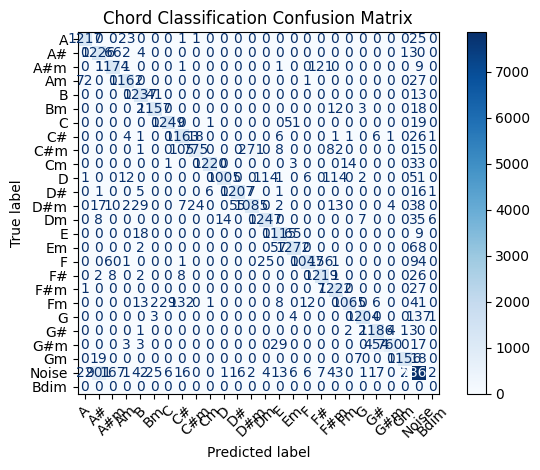

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model = model.float().cpu()

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.float()
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

# Text summary
print(classification_report(all_true, all_preds, target_names=CHORD_CLASSES))

# Visual confusion matrix
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CHORD_CLASSES)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Chord Classification Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


## Test Model with outside recordings

In [22]:
CHORD_CLASSES = ds["train"].features["label"].names + ["Bdim"]

model = build_model(num_classes=26)
checkpoint = torch.load('../models/checkpoints/best_chord_cnn.pth', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])

# Load my recording
chroma, waveform = extract_chroma_cqt("../Datasets/MyRecordings/D_chord.wav")
windows = slice_into_windows(chroma)

# Convert to tensor
features = torch.tensor(np.array(windows), dtype=torch.float32).unsqueeze(1)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(features.float())
    preds = torch.argmax(outputs, dim=1)

# Show predictions per window
for i, pred in enumerate(preds):
    time_sec = i * 512 / 22050
    print(f"{time_sec:.2f}s: {CHORD_CLASSES[pred]}")

0.00s: D
0.02s: D
0.05s: D
0.07s: D
0.09s: D
0.12s: D
0.14s: D
0.16s: D
0.19s: D
0.21s: D
0.23s: D
0.26s: D
0.28s: D
0.30s: D
0.33s: D
0.35s: D
0.37s: D
0.39s: D
0.42s: D
0.44s: D
0.46s: D
0.49s: D
0.51s: D
0.53s: D
0.56s: D
0.58s: D
0.60s: D
0.63s: D
0.65s: D
0.67s: D
0.70s: D
0.72s: D
0.74s: D
0.77s: D
0.79s: D
0.81s: D
0.84s: D
0.86s: D
0.88s: D
0.91s: D
0.93s: D
0.95s: D
0.98s: D
1.00s: D
1.02s: D
1.04s: D
1.07s: D
1.09s: D
1.11s: D
1.14s: D
1.16s: D
1.18s: D
1.21s: D
1.23s: D
1.25s: D
1.28s: D
1.30s: D
1.32s: D
1.35s: D
1.37s: D
1.39s: D
1.42s: D
1.44s: D
1.46s: D
1.49s: D
1.51s: D
1.53s: D
1.56s: D
1.58s: Dm
1.60s: Dm
1.63s: Dm
1.65s: Dm
1.67s: Dm
1.70s: Dm
1.72s: Dm
1.74s: Dm
1.76s: Dm
1.79s: Dm
1.81s: Dm
1.83s: Dm
1.86s: Dm
1.88s: Noise
1.90s: Noise
1.93s: Dm
1.95s: Dm
1.97s: Dm
2.00s: Dm
2.02s: Dm
2.04s: Dm
2.07s: Dm
2.09s: Dm
2.11s: Dm
2.14s: Dm
2.16s: Dm
2.18s: D
2.21s: D
2.23s: D
2.25s: D
2.28s: D
2.30s: D
2.32s: D
2.35s: D
2.37s: D
2.39s: D
2.41s: D
2.44s: D
2.46s: D
2.48s

### Conclusion
Good result. Let's predict another, with a more distorted recording

In [27]:
chroma, waveform = extract_chroma_cqt("../Datasets/MyRecordings/G_Distorted.wav")
windows = slice_into_windows(chroma)

# Convert to tensor
features = torch.tensor(np.array(windows), dtype=torch.float32).unsqueeze(1)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(features.float())
    preds = torch.argmax(outputs, dim=1)

# Show predictions per window
for i, pred in enumerate(preds):
    time_sec = i * 512 / 22050
    print(f"{time_sec:.2f}s: {CHORD_CLASSES[pred]}")

0.00s: Noise
0.02s: Noise
0.05s: Noise
0.07s: G
0.09s: G
0.12s: G
0.14s: G
0.16s: G
0.19s: G
0.21s: G
0.23s: G
0.26s: G
0.28s: G
0.30s: G
0.33s: G
0.35s: G
0.37s: G
0.39s: G
0.42s: G
0.44s: G
0.46s: G
0.49s: G
0.51s: G
0.53s: G
0.56s: G
0.58s: G
0.60s: G
0.63s: G
0.65s: G
0.67s: G
0.70s: G
0.72s: G
0.74s: G
0.77s: G
0.79s: G
0.81s: G
0.84s: G
0.86s: G
0.88s: G
0.91s: G
0.93s: G
0.95s: G
0.98s: G
1.00s: G
1.02s: G
1.04s: G
1.07s: G
1.09s: G
1.11s: G
1.14s: G
1.16s: G
1.18s: G
1.21s: G
1.23s: G
1.25s: G
1.28s: G
1.30s: G
1.32s: G
1.35s: Noise
1.37s: Noise
1.39s: Noise
1.42s: Noise
1.44s: Noise
1.46s: Noise
1.49s: Noise
1.51s: Noise
1.53s: Noise
1.56s: Noise
1.58s: Noise
1.60s: Noise
1.63s: Noise
1.65s: Noise
1.67s: Noise
1.70s: Noise
1.72s: Noise
1.74s: Noise
1.76s: Noise
1.79s: Noise
1.81s: Noise
1.83s: Noise
1.86s: Noise
1.88s: Noise
1.90s: Noise
1.93s: Noise
1.95s: Noise
1.97s: Noise
2.00s: Noise
2.02s: Noise
2.04s: Noise
2.07s: Noise
2.09s: Noise
2.11s: Noise
2.14s: Noise
2.16s: Nois

### Conclusion
Perfect result

### Let's see what happens with a song

In [31]:
chroma, waveform = extract_chroma_cqt("../Datasets/MyRecordings/test_song.wav")
windows = slice_into_windows(chroma)

# Convert to tensor
features = torch.tensor(np.array(windows), dtype=torch.float32).unsqueeze(1)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(features.float())
    preds = torch.argmax(outputs, dim=1)

# Show predictions per window
for i, pred in enumerate(preds):
    time_sec = i * 512 / 22050
    print(f"{time_sec:.2f}s: {CHORD_CLASSES[pred]}")

0.00s: G
0.02s: G
0.05s: G
0.07s: G
0.09s: G
0.12s: G
0.14s: G
0.16s: G
0.19s: G
0.21s: G
0.23s: G
0.26s: G
0.28s: G
0.30s: G
0.33s: G
0.35s: G
0.37s: G
0.39s: G
0.42s: G
0.44s: G
0.46s: G
0.49s: G
0.51s: G
0.53s: G
0.56s: G
0.58s: G
0.60s: G
0.63s: G
0.65s: G
0.67s: G
0.70s: G
0.72s: G
0.74s: G
0.77s: G
0.79s: G
0.81s: G
0.84s: G
0.86s: G
0.88s: G
0.91s: G
0.93s: G
0.95s: G
0.98s: G
1.00s: G
1.02s: G
1.04s: G
1.07s: G
1.09s: G
1.11s: G
1.14s: G
1.16s: G
1.18s: G
1.21s: G
1.23s: G
1.25s: G
1.28s: G
1.30s: G
1.32s: G
1.35s: G
1.37s: G
1.39s: G
1.42s: G
1.44s: G
1.46s: G
1.49s: G
1.51s: G
1.53s: G
1.56s: G
1.58s: G
1.60s: G
1.63s: G
1.65s: G
1.67s: G
1.70s: G
1.72s: G
1.74s: G
1.76s: G
1.79s: G
1.81s: G
1.83s: G
1.86s: G
1.88s: G
1.90s: G
1.93s: G
1.95s: G
1.97s: G
2.00s: G
2.02s: G
2.04s: G
2.07s: G
2.09s: G
2.11s: G
2.14s: G
2.16s: G
2.18s: G
2.21s: G
2.23s: Noise
2.25s: Noise
2.28s: Noise
2.30s: Noise
2.32s: Noise
2.35s: Noise
2.37s: Noise
2.39s: Noise
2.41s: Noise
2.44s: Noise
2.46s:

### Conclusions

Not the worst, but placing a lot of things into the noise category. Anything unrecognized goes to noise

The G sections are strong — the model locks onto G consistently and holds it. D is being detected but split between D and Dm, which is the major/minor confusion during decay. C is the weakest — it's fragmented and often interrupted by Noise. Em comes through but also has some gaps and occasional B/E confusion.